<a href="https://colab.research.google.com/github/cmunozr/2026_I_AI_GU/blob/main/ex3_RF_NB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In this notebook you will compare results from several different classifiers, including Random Forest, SVM and logistic regression ML algorithms

Note that you should start to use Scikit-learns web page to understand more of what you are doing, and learn how to do more. https://scikit-learn.org

When the time comes to try these algorithms with your own data, or data you have gotten from somewhere else, don't forget the usefulness of GitHub
eg, https://github.com/scikit-learn/  AND https://github.com/ageron/handson-mlp

Remember that you can find data on sites such as https://www.kaggle.com/ and this is a good resource too: https://dagshub.com/datasets/

One more tip for when you start using Scikit-learn yourself. Google Gemini and Microsoft Co-pilot (and others) are excellent help for finding code, coding errors, understanding code, etc. Use it!!

In [ ]:
import sys
assert sys.version_info >= (3, 10)

from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

In [2]:
# Common imports
import numpy as np
import os as os

In [3]:
# To plot pretty figures
#Note that you only need this line if you are running in Jupyter Notebook but it doesn't hurt to run it in Google Colab
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=10)
mpl.rc('ytick', labelsize=10)

## IMPORT THE MAKE MOONS DATASET
The Make Moons dataset is used since it is a little more complicated dataset with non-linear relationships between the clusters.

The "make_moons" class generates a 2D binary classification datasets that is challenging to certain algorithms and includes optional Gaussian noise.

If you want to know more about this dataset, you can find it here - https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

You can also generate other datasets in Scikit-learn. See https://scikit-learn.org/stable/datasets/sample_generators.html#sample-generators

In [4]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.datasets import make_moons

# Now you will use the function train_test_split to smoothly divide the dataset into training and test
from sklearn.model_selection import train_test_split

# You can set the number of samples you want to use and add noise to the data
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### Visualizing the Make Moons Dataset

Here's a scatter plot of the `X_train` data, colored by their respective classes from `y_train`. This visualization helps in understanding the non-linear separation challenge posed by this dataset.

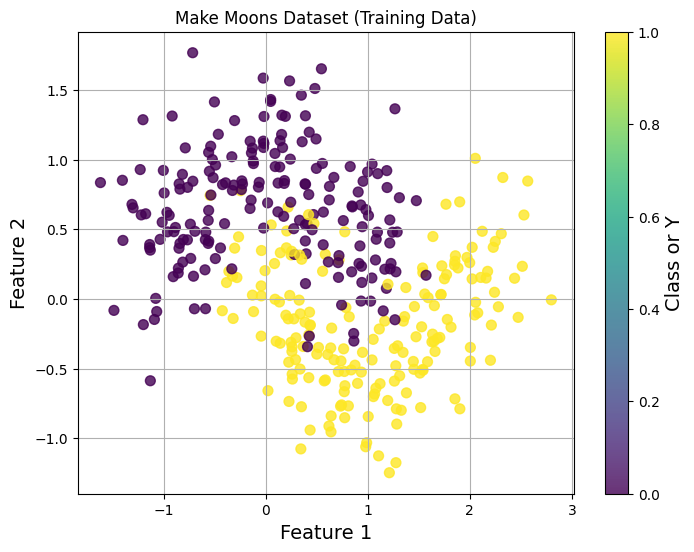

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', marker='o', s=50, alpha=0.8)
plt.title('Make Moons Dataset (Training Data)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.colorbar(label='Class or Y')
plt.show()

The make_moons dataset, as generated in this notebook, doesn't come with explicit string 'headers' like a CSV file would. Instead, it provides data in NumPy arrays:

X (Feature Data): This array contains the input
features for your model. For make_moons, it's a 2D array where:

* Each row represents a single data sample (a point in the 2D space).
* Each column represents a feature. Since make_moons generates 2D data, X will have 2 columns. We can refer to these as 'Feature 1' and 'Feature 2' (as labeled in the plot).
* n_samples is the total number of data points (e.g., 500 in this case).

y (Target Labels): This array contains the corresponding class labels for each sample in X. For make_moons, it's a binary classification problem, so:

* Each value is either 0 or 1, representing one of the two crescent-shaped classes.
* Its shape is (n_samples,), meaning it's a 1D array with one label for each data point.

Want to see the data? You can combine the Features and Target Label and print the first 5 rows

In [6]:
import numpy as np

# Combine X and y for easier viewing
combined_data = np.column_stack((X, y))

print("First 5 rows of X features and y target labels:")
print(combined_data[:5])

First 5 rows of X features and y target labels:
[[ 0.83103915 -0.25874875  1.        ]
 [ 1.18506381  0.92038714  0.        ]
 [ 1.16402213 -0.45552558  1.        ]
 [-0.0236556   1.08628844  0.        ]
 [ 0.48050273  1.50942444  0.        ]]


# An Ensemble Voting Classifier

First we will make a simple voting classifier, based on combining a few different models, namely, Logistic Regression, Random Forest, And Support Vector Machines.

The idea behind the VotingClassifier is to combine conceptually different machine learning classifiers and use a majority vote or the average predicted probabilities (soft vote) to predict the class labels. Such a classifier can be useful for a set of equally well performing models in order to balance out their individual weaknesses. In the following we will combine LR, RF and SVM for classification.


In [7]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [8]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
    ]
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

In [9]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [10]:
voting_clf.predict(X_test[:1])

array([1])

In [11]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([0])]

In [12]:
voting_clf.score(X_test, y_test)

0.912

In [13]:
# OUTPUT THE accuracy results using the following
# First indicate the function in sklearn you want to use, which is "accuracy_score"

from sklearn.metrics import accuracy_score

Maybe you want to see what the accuracy would be if you were to use just a Logistic Regression, RF or SVM alone, compared to an ensemble. The following code allows you to do that.

In [14]:
#Apply your classifiers - all 4 - and assess against the test data

log_clf = LogisticRegression(random_state=42)
rnd_clf = RandomForestClassifier(random_state=42)
svm_clf = SVC(random_state=42)

for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.864
RandomForestClassifier 0.896
SVC 0.896
VotingClassifier 0.912


# Decision trees and Bagging
Now we will run a simple Decision Tree and a Decision Tree with Bagging. This is the basic version, before getting to Random Forest

In [15]:
## DECISION TREE with the same data
## We do this so we can make a plot later and understand what is happening with some simpler decision trees
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [16]:
#Note that if you hover your cursor over the class (eg, BaggingClassifier), that you can see the
#hyperparameters that could be added. You can open in tab to get the full text.

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=100, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)


BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1, random_state=42)

The following code creates a graph that will show you the decision boundaries when running a decision tree vs a decision tree with bagging.

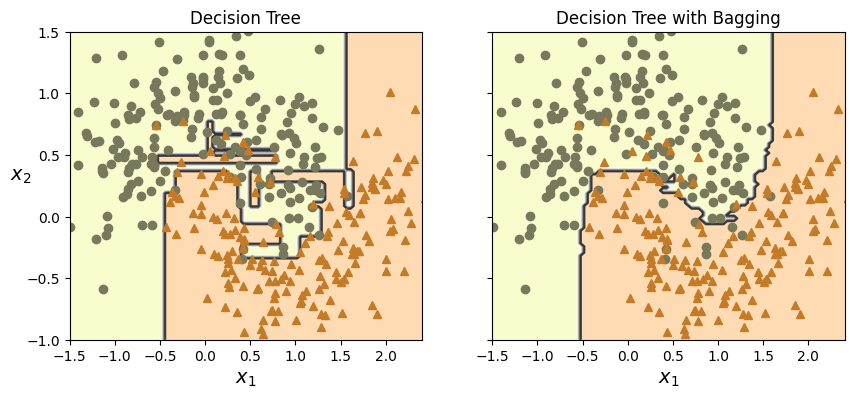

In [17]:
def plot_decision_boundary(clf, X, y, alpha=1.0):
    axes=[-1.5, 2.4, -1, 1.5]
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3 * alpha, cmap='Wistia')
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8 * alpha)
    colors = ["#78785c", "#c47b27"]
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X_train, y_train)
plt.title("Decision Tree")
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train)
plt.title("Decision Tree with Bagging")
plt.ylabel("")

plt.show()

We can assess the accuracy by

In [18]:
from sklearn.metrics import accuracy_score
#For Decision Tree
y_pred_tree = tree_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_tree))

0.856


In [19]:
#For bagging
y_pred_bag = bag_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_bag))

0.904


# Now let's run the random forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                 n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

print(accuracy_score(y_test, y_pred_rf))

0.912


A Random Forest is equivalent to a bag of decision trees

In [21]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, n_jobs=-1, random_state=42)

In [22]:
# extra code – verifies that the predictions are identical
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)
np.all(y_pred_bag == y_pred_rf)  # same predictions


np.True_

In [23]:
print(accuracy_score(y_test, y_pred_bag))

0.912


### Training Data Overview

Here's how to view the number of training samples and a preview of the `X_train` dataset.

In [24]:
print(f"Total number of training samples: {X_train.shape[0]}")
print("\nFirst 5 rows of X_train (serving as header/preview):\n")
print(X_train[:5])

Total number of training samples: 375

First 5 rows of X_train (serving as header/preview):

[[ 1.53869929  0.18874413]
 [ 0.39469854  0.32372361]
 [-0.91914656  1.31188165]
 [ 1.05396355 -0.70040787]
 [ 1.04067847 -0.4373387 ]]


## Hyperparameter Tuning with GridSearchCV and RandomizedSearchCV

We will now use `GridSearchCV` and `RandomizedSearchCV` to find the optimal hyperparameters for the Random Forest Classifier. These techniques automate the process of trying out different parameter combinations and evaluating their performance.

In [25]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

### GridSearchCV for Random Forest

`GridSearchCV` exhaustively searches over specified parameter values for an estimator. It's like trying every possible combination you define in a grid.

In [26]:
# Define the parameter grid for GridSearchCV
param_grid = [
    {
        'bootstrap': [False],
        'n_estimators': [100, 200, 300, 500],
        'max_leaf_nodes': [8, 16, 32],
        'max_features': [3, 5],
        'max_depth': [10, None], # Added max_depth
        'min_samples_split': [2, 5]  # Added min_samples_split
    }
]

forest_clf = RandomForestClassifier(random_state=42)

# Instantiate GridSearchCV
grid_search = GridSearchCV(forest_clf, param_grid, cv=5, scoring='accuracy', return_train_score=True, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best parameters found by GridSearchCV:", grid_search.best_params_)
print("Best accuracy found by GridSearchCV:", grid_search.best_score_)

Best parameters found by GridSearchCV: {'bootstrap': False, 'max_depth': 10, 'max_features': 3, 'max_leaf_nodes': 8, 'min_samples_split': 2, 'n_estimators': 100}
Best accuracy found by GridSearchCV: 0.8959999999999999


You might wonder why GridSearch is giving you a lower accuracy than in the Random Forest and Bagging results above. That is because the GridSearch best score is based on a cross-validation of the training (and internal validation) data -- not the test data.

Below you can determine what the accuracy would be using the test data, given the best hyperparameters found in GridSearch.

In [27]:
print("Accuracy of the best GridSearchCV model on the test set:", grid_search.best_estimator_.score(X_test, y_test))

Accuracy of the best GridSearchCV model on the test set: 0.904


You might still ask yourself - why should the test data give a higher accuracy than the internal validation. I know I did, because it doesn't feel intuitive. However, the Grid Search best score is based on a 5-fold (cv=5) cross-validation and is therefore an average. It is a bit more robust and conservative than the single test set score.

#Now to use a Randomized Search


### RandomizedSearchCV for Random Forest

`RandomizedSearchCV` samples a given number of candidates from a parameter space with a specified distribution. This can be more efficient than `GridSearchCV` when the parameter space is large.

In [28]:
from scipy.stats import randint

# Define the parameter distributions for RandomizedSearchCV
param_distribs = {
    'n_estimators': randint(low=100, high=500),
    'max_features': randint(low=1, high=8),
}

forest_clf_rand = RandomForestClassifier(random_state=42)

# Instantiate RandomizedSearchCV
# n_iter is the number of parameter settings that are sampled
rand_search = RandomizedSearchCV(forest_clf_rand, param_distributions=param_distribs,
                                 n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV to the training data
rand_search.fit(X_train, y_train)

print("Best parameters found by RandomizedSearchCV:", rand_search.best_params_)
print("Best accuracy found by RandomizedSearchCV:", rand_search.best_score_)

Best parameters found by RandomizedSearchCV: {'max_features': 5, 'n_estimators': 120}
Best accuracy found by RandomizedSearchCV: 0.8986666666666668


Think about what the GridSearch and the RandomizedSearch code is doing after you run each. How could you modify the code to suit your purposes?

#More on Random Forest
If you would like to dig deeper into notebooks for Random Forest and Hyperparameter tuning, I can suggest this GitHub resource: [Notebook XXXV 3 Methods for Hyperparameter Tuning with Random Forest.ipynb ](https://github.com/insidelearningmachines/Blog/blob/main/Notebook%20XXXV%203%20Methods%20for%20Hyperparameter%20Tuning%20with%20Random%20Forest.ipynb?utm_source=chatgpt.com)
It also has notebooks for several other algorithms.

You can accompany it with this useful page on Kaggle: [link](https://www.kaggle.com/code/nargisbegum82/hyperparameter-tuning-in-random-forests)

Feel free to incorporate code, eg, Bayesian Optimization, as you like. Otherwise, move forward now with Feature importance and Adaboost.

#Feature Importance

Random Forest can indicate which variables were most important in the splitting of the trees. We will switch over to using the IRIS Dataset now, and see which measurement in the Iris dataset is most critical to identifying the species

In [35]:
from sklearn.datasets import load_iris
iris = load_iris()

#Run the RF Classifier on Iris dataset
rnd_clf_iris = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf_iris.fit(iris["data"], iris["target"])

#Output the feature importance for each feature named
for name, score in zip(iris["feature_names"], rnd_clf_iris.feature_importances_):
    print(name, score)

sepal length (cm) 0.11249225099876375
sepal width (cm) 0.02311928828251033
petal length (cm) 0.4410304643639577
petal width (cm) 0.4233579963547682


## A Note on Feature Imporance using RF

There  are several variations on looking at Feature Variable  Importance with RF. Due to the random nature of RF, you may get a slightly different result each time. if you have an imbalanced dataset, or a rare occurence, you may not get an optimal answer. Remember the idea of causal inference, and that correlation isn't causation, and we only know what we know -- there may be important variables that are missing.

## BOOSTING WITH ADABOOST Classifier


In [36]:
from sklearn.ensemble import AdaBoostClassifier

In [37]:
#Make a function to run AdaBoost
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=30,
    learning_rate=0.5, random_state=42, algorithm="SAMME")
ada_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=30, random_state=42)

In [38]:
y_pred_ada = ada_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_ada))

0.88


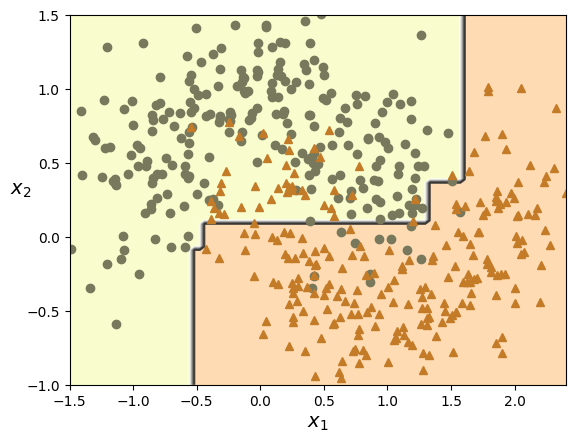

In [39]:
plot_decision_boundary(ada_clf, X, y)

## GRADIENT BOOSTING and REGRESSION


We will first create a simple quadratic dataset to work with. Up until now we have used the Make Moons and Iris datasets only.

In [40]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

m = 100  # number of instances
rng = np.random.default_rng(seed=42)
X = rng.random((m, 1)) - 0.5
noise = 0.05 * rng.standard_normal(m)
y = 3 * X[:, 0] ** 2 + noise  # y = 3x² + Gaussian noise

We will run a DecisionTreeRegressor first, and then a GradientBoostingRegressor for comparison

In [41]:
#Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


In [42]:
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [43]:
from sklearn.metrics import mean_squared_error

#Now to calculate the MSE
y_pred_tree_reg1 = tree_reg1.predict(X_test)
mse_tree_reg1 = mean_squared_error(y_test, y_pred_tree_reg1)
print(f"Mean Squared Error for DecisionTreeRegressor on test set: {mse_tree_reg1:.4f}")

Mean Squared Error for DecisionTreeRegressor on test set: 0.0128


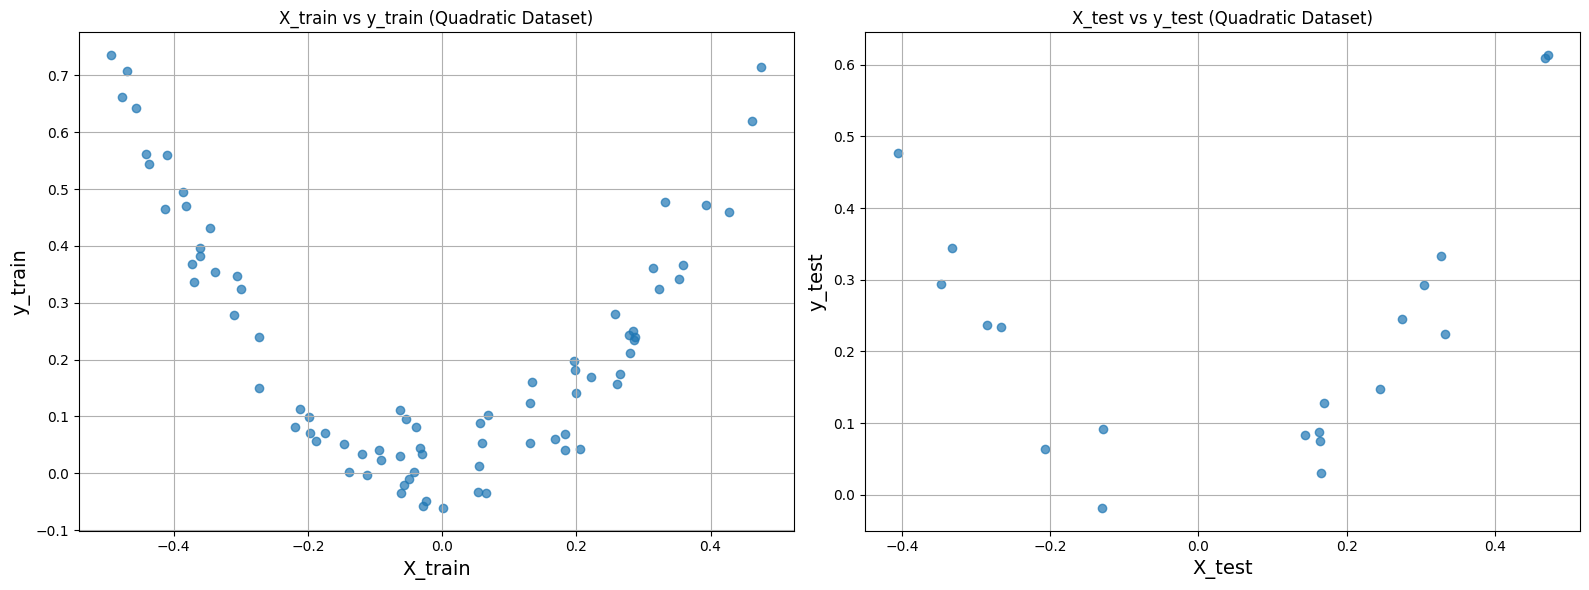

In [44]:
#Perhaps you want to plot the original data next to a plot (on the right) of the Target value vs Predicted value
fig, axes = plt.subplots(ncols=2, figsize=(16, 6))

plt.sca(axes[0])
plt.scatter(X_train, y_train, alpha=0.7)
plt.title('X_train vs y_train (Quadratic Dataset)')
plt.xlabel('X_train')
plt.ylabel('y_train')
plt.grid(True)

plt.sca(axes[1])
plt.scatter(X_test, y_test, alpha=0.7)
plt.title('X_test vs y_test (Quadratic Dataset)')
plt.xlabel('X_test')
plt.ylabel('y_test')
plt.grid(True)

plt.tight_layout()
plt.show()

Let's train a Gradient boosting algorithm with the same data, but adjust the Hyperparameters, such as Learning rate


In [45]:
from sklearn.ensemble import GradientBoostingRegressor


In [46]:
gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3,
                                 learning_rate=1.0, random_state=42)
gbrt.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3,
                          random_state=42)

In [47]:
gbrt.n_estimators_

3

In [48]:
gbrt_best = GradientBoostingRegressor(
    max_depth=2, learning_rate=0.05, n_estimators=500,
    n_iter_no_change=10, random_state=42)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=500,
                          n_iter_no_change=10, random_state=42)

In [49]:
gbrt_best.n_estimators_

31

MAKE A PLOT DEMONSTRATING THE EFFECT OF DIFFERENT LEARNING RATES


In [50]:
# First a function to help in the plots
def plot_predictions(regressors, X_train, y_train, axes, label=None, style="r-", data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)
    plt.plot(X_train[:, 0], y_train, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center", fontsize=16)
    plt.axis(axes)
# End of function

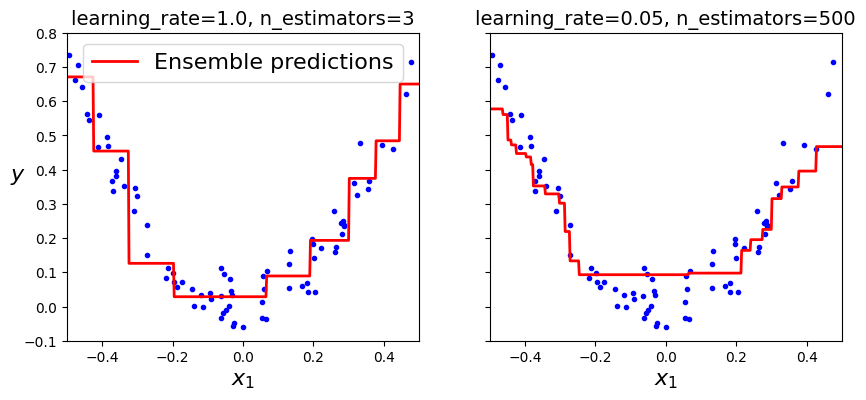

In [51]:
#Now the Plot
fix, axes = plt.subplots(ncols=2, figsize=(10,4), sharey=True)

plt.sca(axes[0])
plot_predictions([gbrt], X_train, y_train, axes=[-0.5, 0.5, -0.1, 0.8], label="Ensemble predictions")
plt.title("learning_rate={}, n_estimators={}".format(gbrt.learning_rate, gbrt.n_estimators), fontsize=14)
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$y$", fontsize=16, rotation=0)

plt.sca(axes[1])
plot_predictions([gbrt_best], X_train, y_train, axes=[-0.5, 0.5, -0.1, 0.8])
plt.title("learning_rate={}, n_estimators={}".format(gbrt_best.learning_rate, gbrt_best.n_estimators), fontsize=14)
plt.xlabel("$x_1$", fontsize=16)

plt.show()

### YOU COULD USE EARLY STOPPING TO CONTROL OVER-FITTING
### BUT HOW MANY TREES ARE OPTIMAL AND WHEN SHOULD YOU STOP?
### YOU CAN USE THE FOLLOWING CODE TO  FIND THE OPTIMAL

In [52]:
from sklearn.metrics import mean_squared_error


In [53]:
gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=120, random_state=42)
gbrt.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=120, random_state=42)

In [54]:
# When is the MSE the lowest?
errors = [mean_squared_error(y_train, y_pred)
          for y_pred in gbrt.staged_predict(X_train)]
bst_n_estimators = np.argmin(errors) + 1
print("Number of estimators giving lowest MSE =", bst_n_estimators)

Number of estimators giving lowest MSE = 120


In [55]:
# You pass the parameter above to the function below
gbrt_best_n = GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators, random_state=42)
gbrt_best_n.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=np.int64(120),
                          random_state=42)

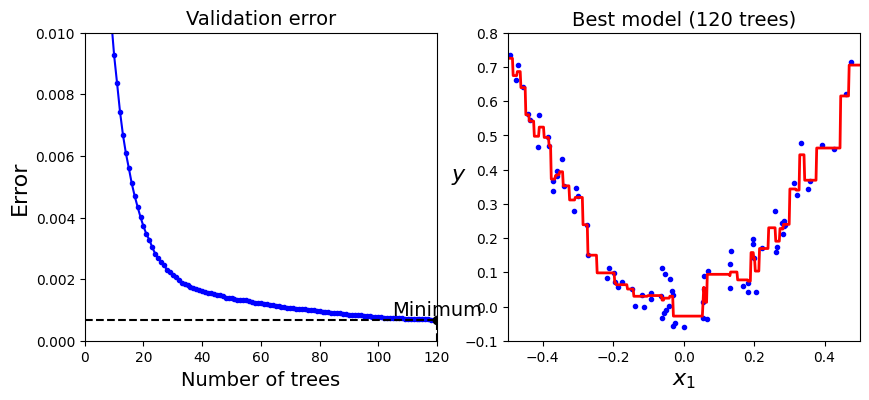

In [56]:
## HERE YOU CAN PLOT TO SEE HOW THIS WORKS IN PRACTICE
min_error = np.min(errors)
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.plot(errors, "b.-")
plt.plot([bst_n_estimators, bst_n_estimators], [0, min_error], "k--")
plt.plot([0, 120], [min_error, min_error], "k--")
plt.plot(bst_n_estimators, min_error, "ko")
plt.text(bst_n_estimators, min_error*1.2, "Minimum", ha="center", fontsize=14)
plt.axis([0, 120, 0, 0.01])
plt.xlabel("Number of trees")
plt.ylabel("Error", fontsize=16)
plt.title("Validation error", fontsize=14)

plt.subplot(122)
plot_predictions([gbrt_best_n], X_train, y_train, axes=[-0.5, 0.5, -0.1, 0.8])
plt.title("Best model (%d trees)" % bst_n_estimators, fontsize=14)
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16)

plt.show()

In [57]:
### PREDICT USING THE BEST RESULT
y_pred_gbrt_best_n = gbrt_best_n.predict(X_test)
print('Minimum Validation MSE:', min_error)

Minimum Validation MSE: 0.000683697999966631


## XGBoost Classifier

XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. It provides a parallel tree boosting (also known as GBDT, GBM) that solves many data science problems in a fast and accurate way.

While not part of the core Scikit-learn library, XGBoost offers a Scikit-learn compatible API, allowing for easy integration with existing Scikit-learn pipelines and tools like `GridSearchCV`.

In [58]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Initialize and train the XGBoost Regressor
xgb_reg = xgb.XGBRegressor(random_state=42)
xgb_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_reg.predict(X_test)

# Evaluate the Mean Squared Error
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print(f"XGBoost Regressor Mean Squared Error: {mse_xgb:.4f}")

XGBoost Regressor Mean Squared Error: 0.0049


The result of this simple run of XGBoost give a higher error. Is there something you can change to see if the model can be better?

### Hyperparameter Tuning XGBoost with RandomizedSearchCV

Just like with `RandomForestClassifier`, you can use `RandomizedSearchCV` (or `GridSearchCV`) to find optimal hyperparameters for `XGBRegressor`. This automates the process of testing different combinations of parameters to see which ones yield the best performance.

Here are some common XGBoost hyperparameters and what they generally control:

*   **`n_estimators`**: The number of boosting rounds or trees to build. More trees can lead to better performance but also increase the risk of overfitting and computation time.
*   **`learning_rate` (`eta`)**: Step size shrinkage used to prevent overfitting. Smaller values make the model more robust to overfitting but require more boosting rounds.
*   **`max_depth`**: The maximum depth of a tree. Used to control overfitting as higher depth allows the model to learn more specific relations but might overfit.
*   **`subsample`**: The fraction of samples (rows) to be used for fitting the individual base learners (trees). Helps prevent overfitting.
*   **`colsample_bytree`**: The fraction of features (columns) to be used for building each tree. Also helps prevent overfitting.
*   **`gamma`**: Minimum loss reduction required to make a further partition on a leaf node of the tree. A larger gamma makes the algorithm more conservative.
*   **`reg_alpha` (L1 regularization)**, **`reg_lambda` (L2 regularization)**: Regularization terms to prevent overfitting.

In [59]:
from scipy.stats import uniform, randint

# Define the parameter distributions for RandomizedSearchCV for XGBRegressor
param_distribs_xgb = {
    'n_estimators': randint(low=100, high=1000),  # Number of boosting rounds
    'learning_rate': uniform(loc=0.01, scale=0.3), # Step size shrinkage
    'max_depth': randint(low=3, high=10),        # Maximum depth of a tree
    'subsample': uniform(loc=0.6, scale=0.4),    # Subsample ratio of the training instance
    'colsample_bytree': uniform(loc=0.6, scale=0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(loc=0, scale=0.2)           # Minimum loss reduction required to make a further partition
}

xgb_reg_rand = xgb.XGBRegressor(random_state=42, n_jobs=-1) # Use all available cores

# Instantiate RandomizedSearchCV
rand_search_xgb = RandomizedSearchCV(
    xgb_reg_rand,
    param_distributions=param_distribs_xgb,
    n_iter=50,  # Number of parameter settings that are sampled (can be increased for more thorough search)
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Using negative MSE as RandomizedSearchCV maximizes scoring
    random_state=42,
    n_jobs=-1   # Use all available cores for parallel processing
)

# Fit RandomizedSearchCV to the training data
rand_search_xgb.fit(X_train, y_train)

print("Best parameters found by RandomizedSearchCV for XGBoost:", rand_search_xgb.best_params_)
print("Best cross-validation MSE found by RandomizedSearchCV for XGBoost:", -rand_search_xgb.best_score_)

# Evaluate the best estimator on the test set
y_pred_xgb_tuned = rand_search_xgb.best_estimator_.predict(X_test)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
print(f"Test set MSE of the best XGBoost model: {mse_xgb_tuned:.4f}")

Best parameters found by RandomizedSearchCV for XGBoost: {'colsample_bytree': np.float64(0.713936197750987), 'gamma': np.float64(0.007377389470906559), 'learning_rate': np.float64(0.19286930019396906), 'max_depth': 4, 'n_estimators': 319, 'subsample': np.float64(0.6205915004999957)}
Best cross-validation MSE found by RandomizedSearchCV for XGBoost: 0.004152132104253192
Test set MSE of the best XGBoost model: 0.0031


SHAP is not built into scikit-learn — it's a separate library (shap) you install independently:

In [ ]:
!pip install shap

You will have to modify the code below in order to get shap values.

In [ ]:
import shap
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor().fit(X_train, y_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0])